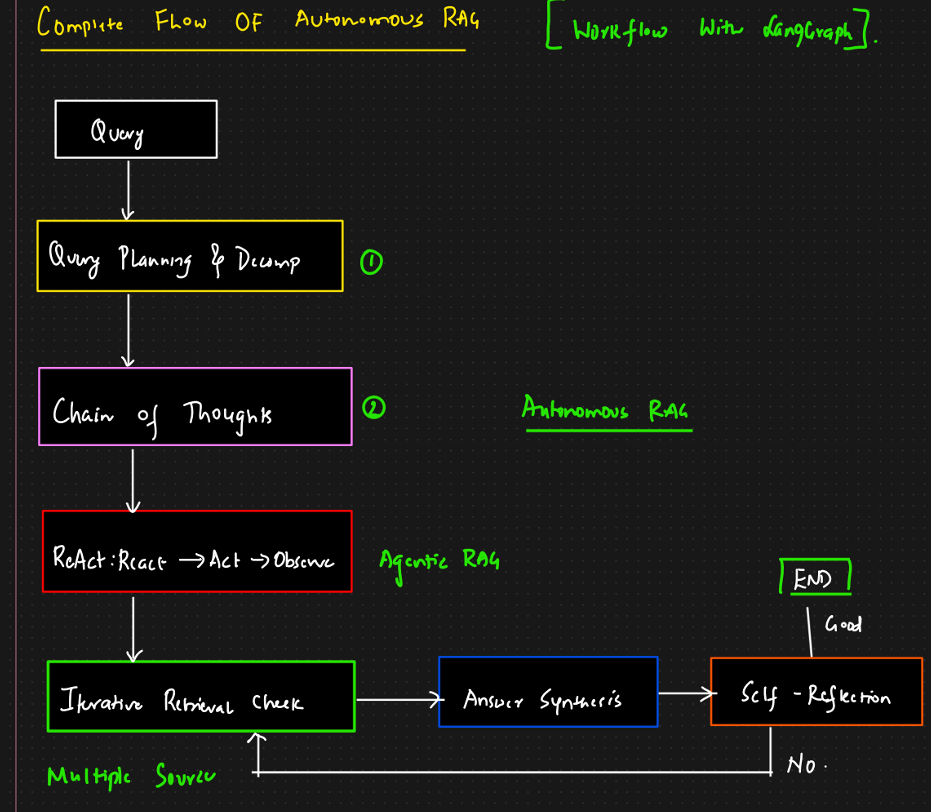

In [8]:
import os
from typing import List, Literal
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders.youtube import YoutubeLoader
from langchain_community.document_loaders import ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.graph import StateGraph, END

In [9]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=init_chat_model("groq:llama-3.3-70b-versatile")

In [10]:
def load_text_retriever(file_path):
    docs = TextLoader(file_path, encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks, HuggingFaceEmbeddings())
    return vs.as_retriever()

# def load_youtube_retriever():
#     # Mocked YouTube transcript text
#     content = """
#     This video explains how agentic AI systems rely on feedback loops, memory, and tool use.
#     It compares them to traditional pipeline-based LLMs. Temporal reasoning and autonomous tasking are emphasized.
#     """
#     doc = Document(page_content=content, metadata={"source": "youtube"})
#     vectorstore = FAISS.from_documents([doc], HuggingFaceEmbeddings())
#     return vectorstore.as_retriever()



# def wikipedia_search(query: str) -> str:
#     print("🌐 Searching Wikipedia...")
#     return WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())(query)

# def arxiv_search(query: str) -> str:
#     print("📄 Searching ArXiv...")
#     results = ArxivLoader(query).load()
#     return "\n\n".join(doc.page_content for doc in results[:2]) or "No relevant papers found."

In [16]:
text_retriever = load_text_retriever("research_notes.txt")
#youtube_retriever = load_youtube_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5544.19it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
### state
class AutonomousRAGState(BaseModel):
    question: str
    decomposed_query: str = ""
    reasoning: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    reflection: str = ""
    attempts: int = 0
    

In [18]:
# ----------------------------
# 3. Nodes
# ----------------------------

## a. Query Planner: splits input question
def plan_query(state: AutonomousRAGState) -> AutonomousRAGState:
   
    prompt = f"""
Break the following complex question into 2-3 sub-questions:

Question: {state.question}

Sub-questions:
"""
    response = llm.invoke(prompt).content
    
    return state.model_copy(
        update={
            "decomposed_query": response
        }
    )

# -------------------------
# b. Chain of Thought
# -------------------------
def chain_of_thought(state: AutonomousRAGState):
    prompt = f"""
Think step-by-step how this query should be solved.

Original Query:
{state.question}

Sub Queries:
{state.decomposed_query}
"""
    response = llm.invoke(prompt).content

    return state.model_copy(
        update={
            "reasoning": response
        }
    )

# -------------------------
# c. ReAct Agent Node
# -------------------------
def react_reason_act_observe(state: AutonomousRAGState):
    prompt = f"""
Use ReAct style reasoning:

Question: {state.question}

Reasoning:
{state.reasoning}

Generate:
Thought:
Action:
Observation:
"""
    response = llm.invoke(prompt).content

    return state.model_copy(
        update={
            "reasoning": state.reasoning + "\n\n" + response
        }
    )

# -------------------------
# d. Iterative Retrieval Check
# -------------------------
def iterative_retrieval(state: AutonomousRAGState):
    docs = text_retriever.invoke(state.question)

    return state.model_copy(
        update={
            "retrieved_docs": docs,
            "attempts": state.attempts + 1
        }
    )
# -------------------------
# e. Answer Synthesis
# -------------------------
def answer_synthesis(state: AutonomousRAGState):
    context = "\n\n".join(
        [doc.page_content for doc in state.retrieved_docs]
    )

    prompt = f"""
Use retrieved documents to answer.

Question:
{state.question}

Context:
{context}
"""

    response = llm.invoke(prompt).content

    return state.model_copy(
        update={
            "answer": response
        }
    )
# -------------------------
# f. Self Reflection
# -------------------------
def self_reflection(state: AutonomousRAGState):
    prompt = f"""
Evaluate the answer.

Question:
{state.question}

Answer:
{state.answer}

Return:

Reflection: YES/NO
Reason:
"""
    response = llm.invoke(prompt).content

    return state.model_copy(
        update={
            "reflection": response
        }
    )

# -------------------------
# g. Conditional Router
# -------------------------
def reflection_router(state: AutonomousRAGState) -> Literal["retry", "end"]:
    
    reflection = state.reflection.lower()

    if "yes" in reflection:
        return "end"

    if state.attempts >= 3:
        return "end"

    return "retry"

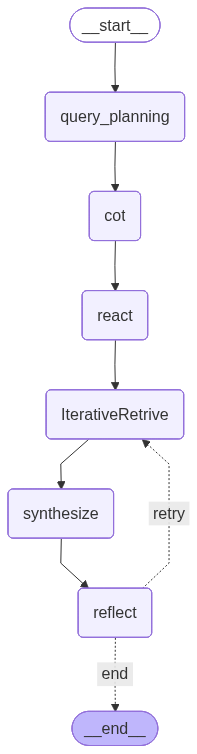

In [19]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(AutonomousRAGState)
builder.add_node("query_planning", plan_query)
builder.add_node("cot", chain_of_thought)
builder.add_node("react", react_reason_act_observe)
builder.add_node("IterativeRetrive", iterative_retrieval)
builder.add_node("synthesize", answer_synthesis)
builder.add_node("reflect", self_reflection)

builder.set_entry_point("query_planning")

builder.add_edge("query_planning", "cot")
builder.add_edge("cot", "react")
builder.add_edge("react", "IterativeRetrive")
builder.add_edge("IterativeRetrive", "synthesize")
builder.add_edge("synthesize", "reflect")

builder.add_conditional_edges(
    "reflect",
    reflection_router,
    {
        "retry": "IterativeRetrive",
        "end": END
    }
)

graph = builder.compile()
graph

In [20]:

# -------------------------
# 12. Run
# -------------------------
query = "What are transformer variants used in production AI systems?"

state = AutonomousRAGState(
    question=query
)

result = graph.invoke(state)

print("\nFinal Answer:\n")
print(result["answer"])

print("\nReflection:\n")
print(result["reflection"])

print("\nAttempts:")
print(result["attempts"])


Final Answer:

Based on the retrieved documents, the following transformer variants are used in production AI systems:

1. **EfficientFormer**: Deployed on Raspberry Pi 4 for image classification tasks, such as TinyImageNet, with a top-1 accuracy of 92.4%.
2. **TinyBERT**: Used for classification tasks, such as support ticket priority tagging, with an F1 score of 87%.
3. **Longformer**: Evaluated for use in customer support logs, but may require optimization to reduce latency.
4. **LLaMA2**: Used as a base model for instruction-tuned chatbots, combined with RAG for question-answering tasks, with a latency of ~300ms on A100 hardware.
5. **FlashAttention2**: Integrated into LLaMA2 to reduce context latency by ~50%.

These transformer variants are being used in various production AI systems, including image classification, natural language processing, and chatbot applications.

Reflection:

Reflection: YES
Reason: The answer provides specific examples of transformer variants used in prod